# CH04-Q13(P196)
<h3>
This question should be answered using the Weekly data set, which
is part of the ISLP package. This data is similar in nature to the
Smarket data from this chapter’s lab, except that it contains 1, 089
weekly returns for 21 years, from the beginning of 1990 to the end of
2010.

### (a) Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

In [1]:
from ISLP import load_data
Weekly = load_data('Weekly')
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
excpt = Weekly.select_dtypes(include='number')
desc = excpt.describe().T
desc['skew'] = excpt.skew()
desc['kurtosis'] = excpt.kurt()

print(desc)
print(Weekly['Direction'].value_counts())

         count         mean       std          min          25%         50%  \
Year    1089.0  2000.048669  6.033182  1990.000000  1995.000000  2000.00000   
Lag1    1089.0     0.150585  2.357013   -18.195000    -1.154000     0.24100   
Lag2    1089.0     0.151079  2.357254   -18.195000    -1.154000     0.24100   
Lag3    1089.0     0.147205  2.360502   -18.195000    -1.158000     0.24100   
Lag4    1089.0     0.145818  2.360279   -18.195000    -1.158000     0.23800   
Lag5    1089.0     0.139893  2.361285   -18.195000    -1.166000     0.23400   
Volume  1089.0     1.574618  1.686636     0.087465     0.332022     1.00268   
Today   1089.0     0.149899  2.356927   -18.195000    -1.154000     0.24100   

                75%          max      skew  kurtosis  
Year    2005.000000  2010.000000 -0.002110 -1.203829  
Lag1       1.405000    12.026000 -0.481967  5.716526  
Lag2       1.409000    12.026000 -0.482295  5.713458  
Lag3       1.409000    12.026000 -0.480154  5.670682  
Lag4       1.

This table shows that the lag1-5 average returns are close to 15% with negative skewness and high kurtosis, and volume is positively skewed. The direction up has 605 times, while down is 484, indicating an overall upward market trend.

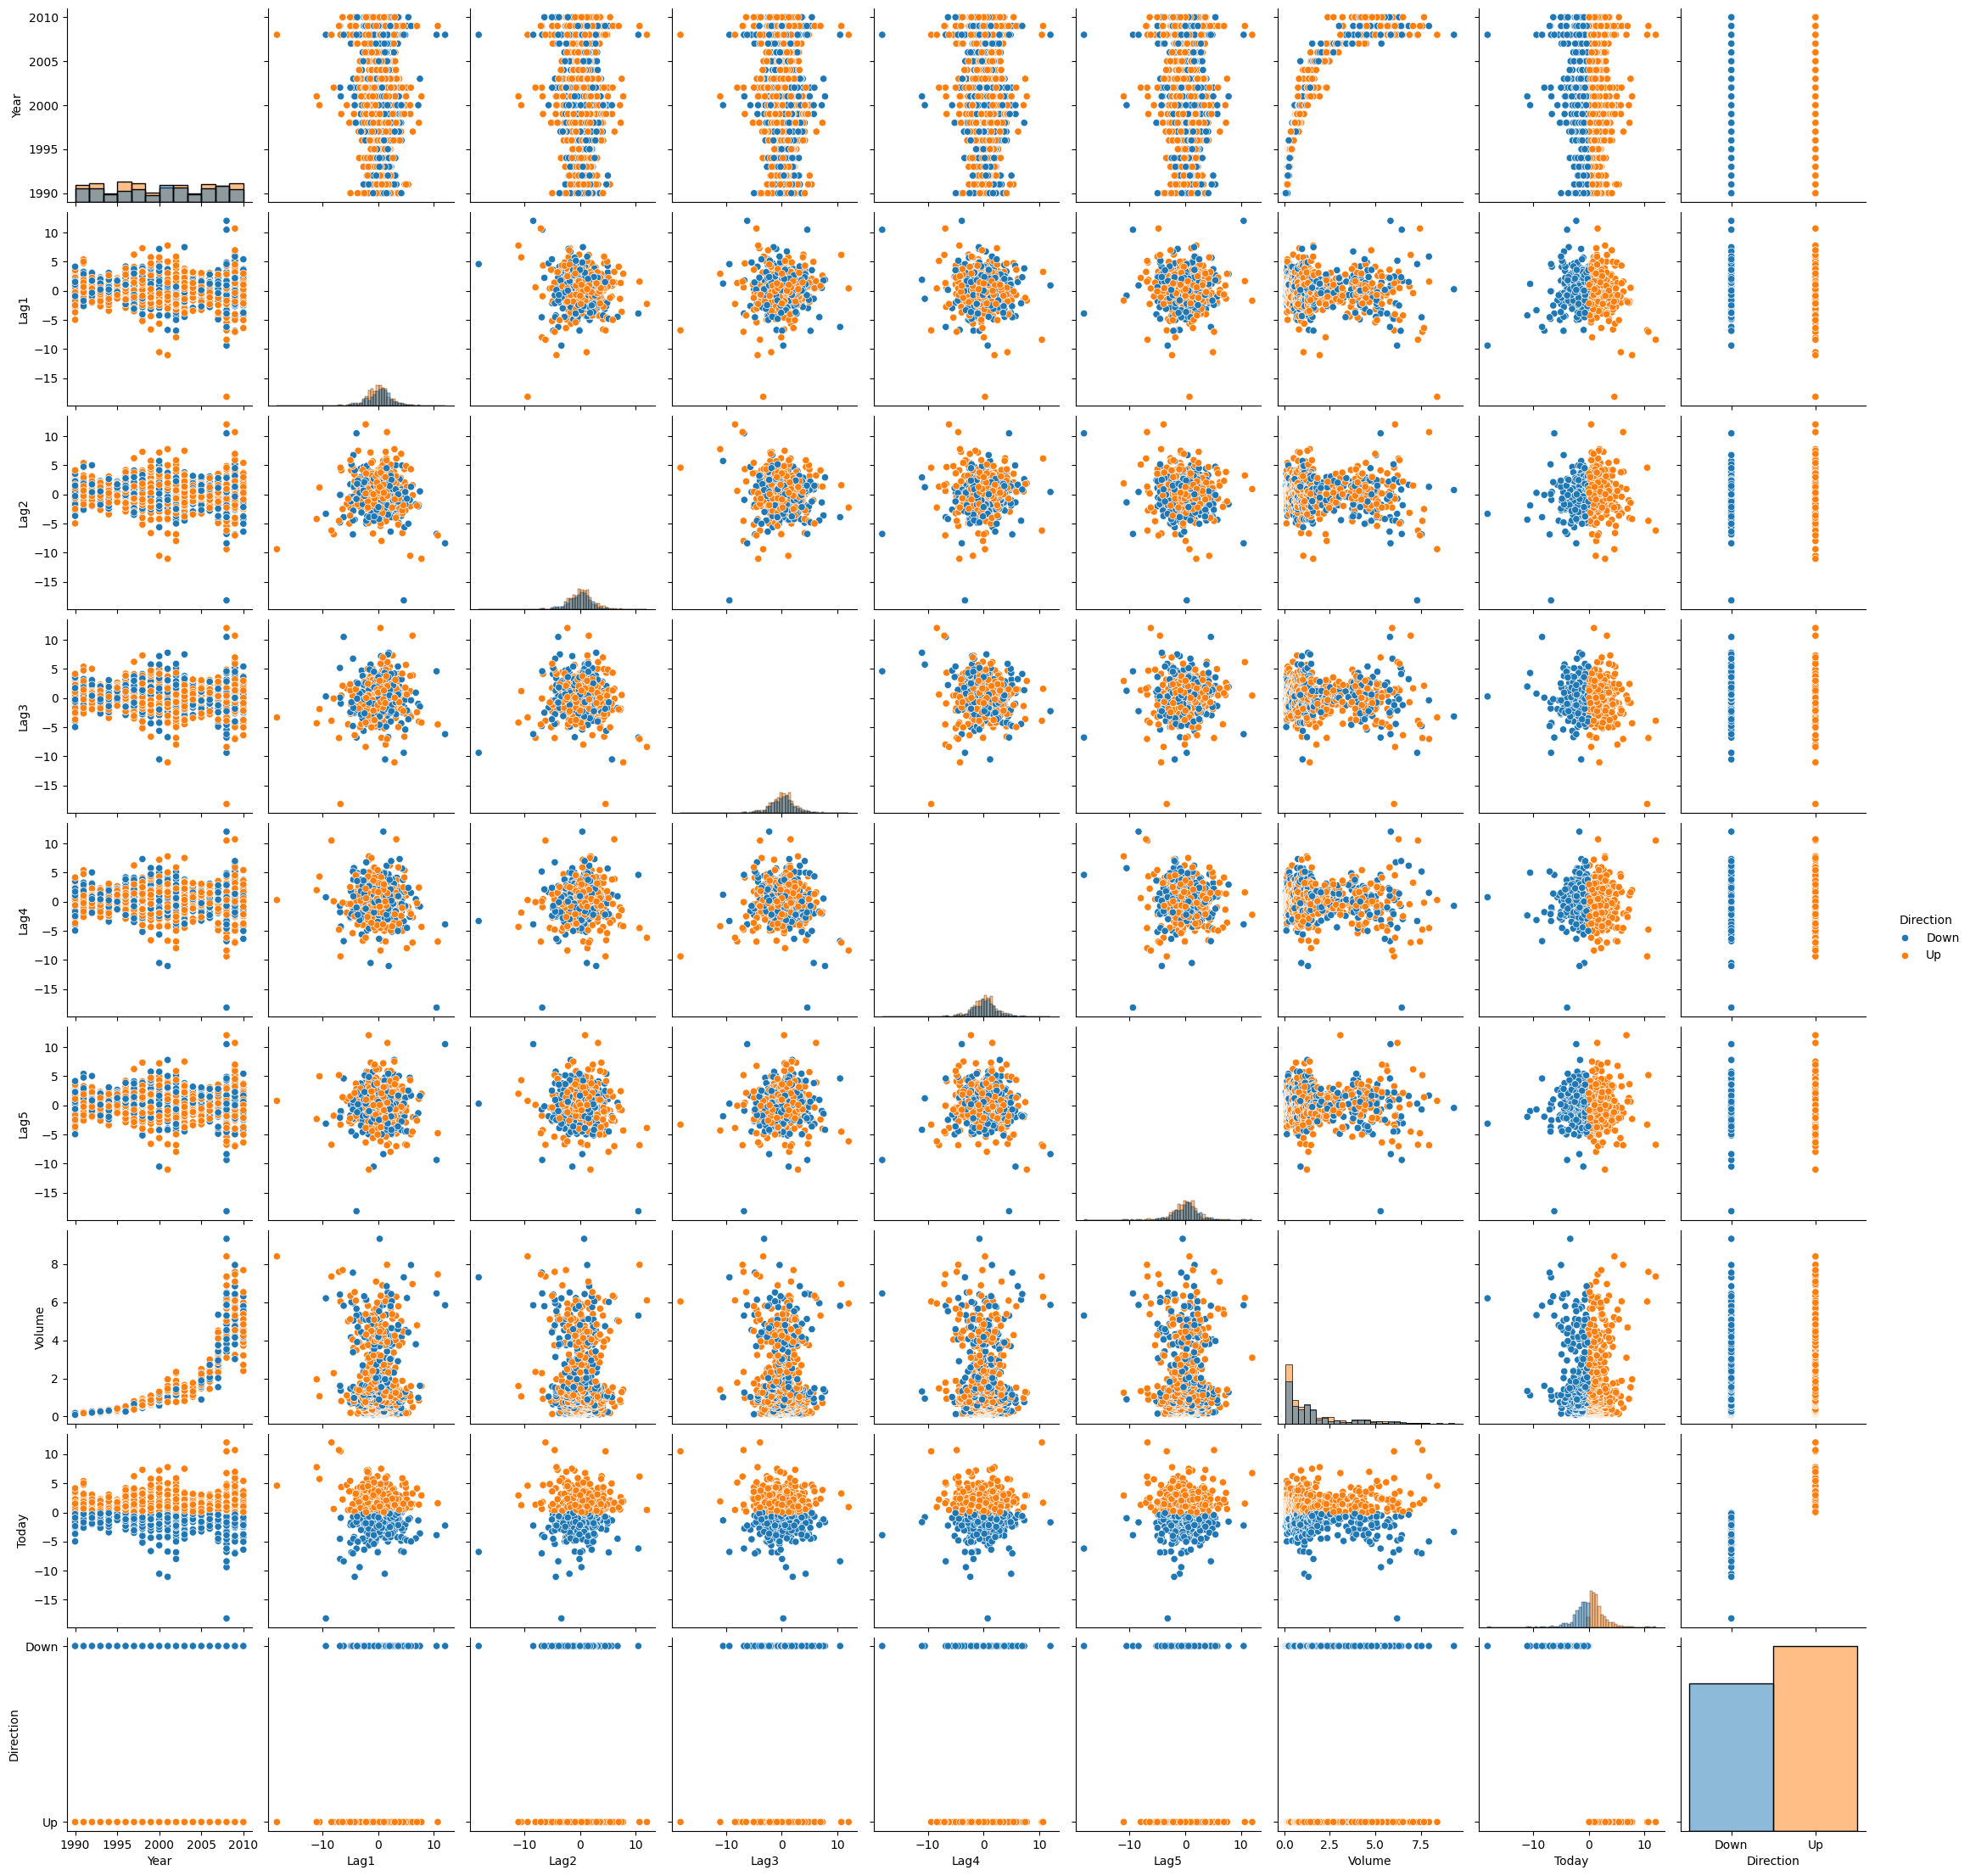

In [ ]:
col = Weekly.columns.to_list()
sns.pairplot(Weekly, vars=col, hue='Direction', diag_kind='hist')
plt.show()

In this plot, blue represents the down signal and orange represents the up signal. Year vs volume shows volume is increasing over time. There is no significant trend between Today and lag1-5 returns. No strong linear or nonlinear patterns are observed, except for a clear upward trend in volume over the years.

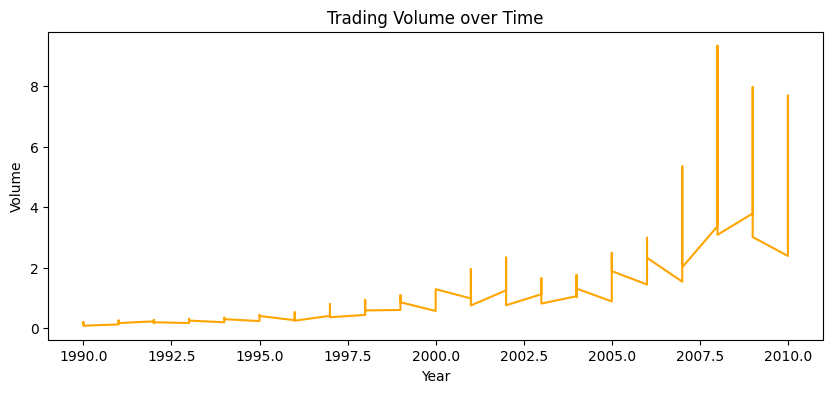

In [16]:
plt.figure(figsize=(10,4))
plt.plot(Weekly['Year'], Weekly['Volume'], color='orange')
plt.title("Trading Volume over Time")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.show()

a upward trend in volume over the years

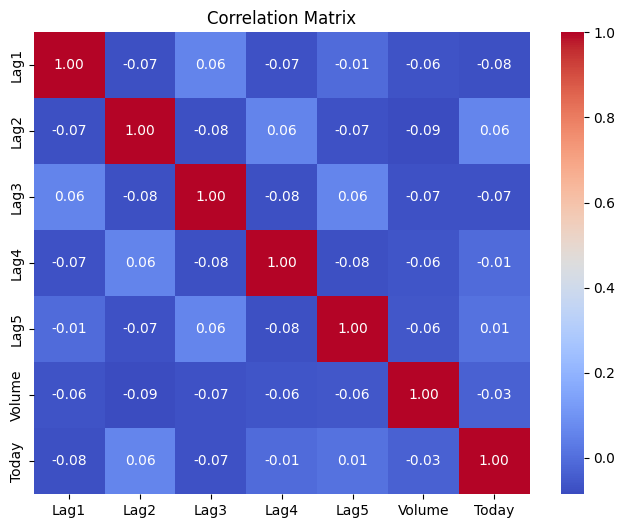

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume','Today']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

there is lower correlation between lag1-5 returns and today return

### (b) Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [19]:
import statsmodels.api as sm

X = Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
X = sm.add_constant(X) 
# Target variable: 1 for 'Up', 0 for 'Down'
y = (Weekly['Direction'] == 'Up').astype(int) 

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Thu, 30 Oct 2025   Pseudo R-squ.:                0.006580
Time:                        03:26:51   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

Based on the results, only Lag2 has a statistically significant result at the 5% level, which means returns from two weeks ago can predict the current week's direction (up/down), other predictors do not show a statistically significant result.

### (c) Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

In [20]:
y_pred_prob = result.predict(X)
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = y

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd


cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
cm_df = pd.DataFrame(
    cm,
    columns=['True Up', 'True Down'],
    index=['Predicted Up', 'Predicted Down']
)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, pos_label=1)

print("\nConfusion Matrix:")
print(cm_df)
print("\nAccuracy :", round(acc, 3))
print("F1-score :", round(f1, 3))


Confusion Matrix:
                True Up  True Down
Predicted Up        557         48
Predicted Down      430         54

Accuracy : 0.561
F1-score : 0.7


accuracy is 56.1% and f1-score is 70%, model has limited ability to capture market direction.

* accuracy = (TP+TN)/(TP+TN+FP+FN)
* f1-score =  2*(precision*recall)/(precision+recall)
* Precision = TP/(TP+FP)
* recall = TP/(TP+FN)

### (d) Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

In [39]:
train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

X_train = sm.add_constant(train['Lag2'])
y_train = (train['Direction'] == 'Up').astype(int)
X_test = sm.add_constant(test['Lag2'])
y_test = (test['Direction'] == 'Up').astype(int)

model = sm.Logit(y_train, X_train)
result = model.fit()
print(result.summary())

y_pred_prob = result.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
cm_df = pd.DataFrame(cm,
                     index=['Predicted Up', 'Predicted Down'],
                     columns=['True Up', 'True Down'])

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("\nConfusion Matrix:")
print(cm_df)
print("\nAccuracy:", round(acc, 3))
print("F1-score:", round(f1, 3))

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Oct 2025   Pseudo R-squ.:                0.003076
Time:                        04:08:55   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.

accuracy is 62.5% and f1-score is 74.2%, the performance of this model is better than last one(c). and combining with Log2 appears to be statistically significant in (b), log2 provides a power for future market direction during the 2009–2010 period.